## 1. Feladat

In [1]:
# Beolvassuk a fájlokat és ránézünk az adatok struktúrájára 

import pandas as pd

population = pd.read_csv("world-population.csv")
covid = pd.read_csv("covid-cases.csv")

# A dátumot megfelelő formátumra hozzuk, hogy műveleteket lehessen vele végezni
# Majd megnézzük, hogy milyen értékek között is mozognak

print(covid.dtypes)

covid['Date_reported'] = pd.to_datetime(covid['Date_reported'])

min_date = covid['Date_reported'].min()
max_date = covid['Date_reported'].max()

print(f"A dátumok {min_date.date()} és {max_date.date()} között vannak.")

# Az adatok alapján 3 időszakot határozunk meg, amikben külön vizsgálódunk:
# 1. hullám: 2020-07-31-ig
# 2. hullám: 2020-08-01 és 2021-01-31 között
# 3. hullám: 2021-02-01-től

# Ezek nagyjából a hivatalos felosztások is, és mivel több időszakban kell vizsgálódnunk, ennél a felosztásnál maradtunk

# 1. FELADAT - OSRZÁGOK SZERINTI ELEMZÉS

# Elsőnek a fent említett dátumok mentén három hullámra vágjuk az adatbázist

elso_hullam = covid[covid['Date_reported'] <= '2020-07-31']
masodik_hullam = covid[
    (covid['Date_reported'] >= '2020-08-01') &
    (covid['Date_reported'] <= '2021-01-31')
]
harmadik_hullam = covid[covid['Date_reported'] >= '2021-02-01']

# Kellően sok adat van mindegyik időszakban

print(elso_hullam.shape)
print(masodik_hullam.shape)
print(harmadik_hullam.shape)

# Mivel aggragált adataink is vannak, így ha minden hullámban megnézzük az utolsó értéket (ami egyben biztosan a legnagyobb is),
# és ezt országok szerint csoportosítva tesszük, akkor majdnem meg is kapjuk az összes esetszámot egy adott időszakban az országra nézve

hullam1 = elso_hullam.groupby('Country', as_index=False).agg({
    'Cumulative_cases': 'max',
    'Cumulative_deaths': 'max'
})

hullam2 = masodik_hullam.groupby('Country', as_index=False).agg({
    'Cumulative_cases': 'max',
    'Cumulative_deaths': 'max'
})

hullam3 = harmadik_hullam.groupby('Country', as_index=False).agg({
    'Cumulative_cases': 'max',
    'Cumulative_deaths': 'max'
})

# Annyit kell még tennünk, hogy a harmadik hullám szummájából kivonjuk a másodikat és a másodikból az elsőt, hiszen a kummulálás azokat is tartalmazta

hullam3['Cumulative_cases'] = hullam3['Cumulative_cases'] - hullam2['Cumulative_cases']
hullam3['Cumulative_deaths'] = hullam3['Cumulative_deaths'] - hullam2['Cumulative_deaths']

hullam2['Cumulative_cases'] = hullam2['Cumulative_cases'] - hullam1['Cumulative_cases']
hullam2['Cumulative_deaths'] = hullam2['Cumulative_deaths'] - hullam1['Cumulative_deaths']

# Ezen a ponton a két adatbázist az országok neve mentén mergeljük
# Erre azért van szükség, hogy a megfelelő országhoz tartozó népességszámmal tudjunk osztani

hullam1_merged = hullam1.merge(
    population,
    left_on='Country',
    right_on='Name',
    how='inner'
)

hullam2_merged = hullam2.merge(
    population,
    left_on='Country',
    right_on='Name',
    how='inner'
)

hullam3_merged = hullam3.merge(
    population,
    left_on='Country',
    right_on='Name',
    how='inner'
)

# Az első két hullámhoz a 2020-as népesség adatokat használjuk, a harmadik hullámhoz pedig a 2022 évit
# Ennél részletesebb adat nem áll rendelkezésre, de a hullámok átlagosan az adott években zajlottak, amivel számolunk

# Országonként leosztjuk az eset- illetve a halálozási számokat, és megkerssük a legnagyobb törtet

hullam1_merged['esetszám_népességarányos'] = hullam1_merged["Cumulative_cases"]/hullam1_merged["2020"]
hullam1_eset_max = hullam1_merged.loc[
    hullam1_merged['esetszám_népességarányos'] == hullam1_merged['esetszám_népességarányos'].max()
]

hullam1_merged['halál_népességarányos'] = hullam1_merged["Cumulative_deaths"]/hullam1_merged["2020"]
hullam1_halal_max = hullam1_merged.loc[
    hullam1_merged['halál_népességarányos'] == hullam1_merged['halál_népességarányos'].max()
]

# Egész mondatban megjelenítjük a legjobban súlytott országot és a hozzá tartozó arányszámot

print(f"Népességarányosan legtöbb esetszámot elszenvedő ország az első hullámban: {hullam1_eset_max['Country'].values[0]}")
print(f"Az esetszám/1000 fő: {round(hullam1_eset_max['esetszám_népességarányos'].values[0], 3)}")
print("")
print(f"Népességarányosan legtöbb halált elszenvedő ország az első hullámban: {hullam1_halal_max['Country'].values[0]}")
print(f"A halálozási szám/1000 fő: {round(hullam1_halal_max['halál_népességarányos'].values[0], 3)}")

# A fenti módszert megismételjük pontosan ugyanúgy a második hullámra

hullam2_merged['esetszám_népességarányos'] = hullam2_merged["Cumulative_cases"]/hullam2_merged["2020"]
hullam2_eset_max = hullam2_merged.loc[
    hullam2_merged['esetszám_népességarányos'] == hullam2_merged['esetszám_népességarányos'].max()
]

hullam2_merged['halál_népességarányos'] = hullam2_merged["Cumulative_deaths"]/hullam2_merged["2020"]
hullam2_halal_max = hullam2_merged.loc[
    hullam2_merged['halál_népességarányos'] == hullam2_merged['halál_népességarányos'].max()
]

print(f"Népességarányosan legtöbb esetszámot elszenvedő ország a második hullámban: {hullam2_eset_max['Country'].values[0]}")
print(f"Az esetszám/1000 fő: {round(hullam2_eset_max['esetszám_népességarányos'].values[0], 3)}")
print("")
print(f"Népességarányosan legtöbb halált elszenvedő ország a második hullámban: {hullam2_halal_max['Country'].values[0]}")
print(f"A halálozási szám/1000 fő: {round(hullam2_halal_max['halál_népességarányos'].values[0], 3)}")

# Majd a harmadikra is

hullam3_merged['esetszám_népességarányos'] = hullam3_merged["Cumulative_cases"]/hullam3_merged["2022"]
hullam3_eset_max = hullam3_merged.loc[
    hullam3_merged['esetszám_népességarányos'] == hullam3_merged['esetszám_népességarányos'].max()
]

hullam3_merged['halál_népességarányos'] = hullam3_merged["Cumulative_deaths"]/hullam3_merged["2022"]
hullam3_halal_max = hullam3_merged.loc[
    hullam3_merged['halál_népességarányos'] == hullam3_merged['halál_népességarányos'].max()
]

print(f"Népességarányosan legtöbb esetszámot elszenvedő ország a harmadik hullámban: {hullam3_eset_max['Country'].values[0]}")
print(f"Az esetszám/1000 fő: {round(hullam3_eset_max['esetszám_népességarányos'].values[0], 3)}")
print("")
print(f"Népességarányosan legtöbb halált elszenvedő ország a harmadik hullámban: {hullam3_halal_max['Country'].values[0]}")
print(f"A halálozási szám/1000 fő: {round(hullam3_halal_max['halál_népességarányos'].values[0], 3)}")


Date_reported        object
Country_code         object
Country              object
WHO_region           object
New_cases             int64
Cumulative_cases      int64
New_deaths            int64
Cumulative_deaths     int64
dtype: object
A dátumok 2020-01-03 és 2023-09-27 között vannak.
(50007, 8)
(43608, 8)
(229653, 8)
Népességarányosan legtöbb esetszámot elszenvedő ország az első hullámban: Qatar
Az esetszám/1000 fő: 40.022

Népességarányosan legtöbb halált elszenvedő ország az első hullámban: Peru
A halálozási szám/1000 fő: 1.651
Népességarányosan legtöbb esetszámot elszenvedő ország a második hullámban: Gibraltar
Az esetszám/1000 fő: 118.485

Népességarányosan legtöbb halált elszenvedő ország a második hullámban: Gibraltar
A halálozási szám/1000 fő: 2.212
Népességarányosan legtöbb esetszámot elszenvedő ország a harmadik hullámban: Faroe Islands
Az esetszám/1000 fő: 641.528

Népességarányosan legtöbb halált elszenvedő ország a harmadik hullámban: Bulgaria
A halálozási szám/1000 fő: 

## 2. Feladat

In [2]:
# 2. FELADAT - WHO RÉGIÓ SZINTŰ ELEMZÉS

# Itt első lépésben elvégezzük a teljes adatbázisokra a mergelést

WHO_merged = covid.merge(
    population,
    left_on='Country',
    right_on='Name',
    how='inner'
)

WHO_merged

# Ezek után az országokhoz hasonlóan a hullámok dátumai mentén feldaraboljuk az adatbázist 

WHO_elso_hullam = WHO_merged[WHO_merged['Date_reported'] <= '2020-07-31']
WHO_masodik_hullam = WHO_merged[
    (WHO_merged['Date_reported'] >= '2020-08-01') &
    (WHO_merged['Date_reported'] <= '2021-01-31')
]
WHO_harmadik_hullam = WHO_merged[WHO_merged['Date_reported'] >= '2021-02-01']

print(WHO_elso_hullam.shape)
print(WHO_masodik_hullam.shape)
print(WHO_harmadik_hullam.shape)


# Majd szintén ugyanazt a logikát használva most WHO régiók mentén aggregálunk és keressük meg a maximumokat

WHO_hullam1 = WHO_elso_hullam.groupby('WHO_region', as_index=False).agg({
    'Cumulative_cases': 'max',
    'Cumulative_deaths': 'max',
})

WHO_hullam2 = WHO_masodik_hullam.groupby('WHO_region', as_index=False).agg({
    'Cumulative_cases': 'max',
    'Cumulative_deaths': 'max',
})

WHO_hullam3 = WHO_harmadik_hullam.groupby('WHO_region', as_index=False).agg({
    'Cumulative_cases': 'max',
    'Cumulative_deaths': 'max',
})

# És szintén korrigálunk, hogy a második és harmadik hullám ne tartalmazza a korábbi hullámok adatait

WHO_hullam3['Cumulative_cases'] = WHO_hullam3['Cumulative_cases'] - WHO_hullam2['Cumulative_cases']
WHO_hullam3['Cumulative_deaths'] = WHO_hullam3['Cumulative_deaths'] - WHO_hullam2['Cumulative_deaths']

WHO_hullam2['Cumulative_cases'] = WHO_hullam2['Cumulative_cases'] - WHO_hullam1['Cumulative_cases']
WHO_hullam2['Cumulative_deaths'] = WHO_hullam2['Cumulative_deaths'] - WHO_hullam1['Cumulative_deaths']

WHO_hullam3.head(6)

# Itt létrehozunk egy segéd dataframe-t, amiben minden ország csak egyszer szerepel
# Mivel a WHO régiók népességszámai nem állnak rendelkezésre explicit módon, ezeket a megfelelő országok összeadásából tudjuk megkapni
# Így minden országot csak egyszer számolunk, és megfelelő lesz a szumma értéke

WHO_unique = WHO_merged.drop_duplicates(subset='Country', keep='first')

WHO_population = WHO_unique.groupby('WHO_region', as_index=False).agg({
  '2020': 'sum',
  '2022': 'sum'
}
)

# Ellenőrizzük az értékeket, és reális népességszámok jöttek ki

WHO_population

# A következő 3 cellában pedig pontosan ugyanazt csinálom, mint az országok esetében:
# A régiók esetszámait és halálozási adatait leosztjuk a megfelelő népességszámmal
# Megkeresem, melyik régió a legsúlyosabb, és hogy mekkora ez a legnagyobb arány
# Megfelelő kontextusban kiírom e megoldásokat

WHO_hullam1['esetszám_népességarányos'] = WHO_hullam1["Cumulative_cases"]/WHO_population["2020"]
WHO_hullam1_eset_max = WHO_hullam1.loc[
    WHO_hullam1['esetszám_népességarányos'] ==  WHO_hullam1['esetszám_népességarányos'].max()
]

WHO_hullam1['halál_népességarányos'] = WHO_hullam1["Cumulative_deaths"]/WHO_population["2020"]
WHO_hullam1_halal_max = WHO_hullam1.loc[
    WHO_hullam1['halál_népességarányos'] == WHO_hullam1['halál_népességarányos'].max()
]

print(f"Népességarányosan legtöbb esetszámot elszenvedő WHO régió az első hullámban: {WHO_hullam1_eset_max['WHO_region'].values[0]}")
print(f"Az esetszám/1000 fő: {round(WHO_hullam1_eset_max['esetszám_népességarányos'].values[0], 3)}")
print("")
print(f"Népességarányosan legtöbb halált elszenvedő WHO régió az első hullámban: {WHO_hullam1_halal_max['WHO_region'].values[0]}")
print(f"A halálozási szám/1000 fő: {round(WHO_hullam1_halal_max['halál_népességarányos'].values[0], 3)}")

WHO_hullam2['esetszám_népességarányos'] = WHO_hullam2["Cumulative_cases"]/WHO_population["2020"]
WHO_hullam2_eset_max = WHO_hullam2.loc[
    WHO_hullam2['esetszám_népességarányos'] ==  WHO_hullam2['esetszám_népességarányos'].max()
]

WHO_hullam2['halál_népességarányos'] = WHO_hullam2["Cumulative_deaths"]/WHO_population["2020"]
WHO_hullam2_halal_max = WHO_hullam2.loc[
    WHO_hullam2['halál_népességarányos'] == WHO_hullam2['halál_népességarányos'].max()
]

print(f"Népességarányosan legtöbb esetszámot elszenvedő WHO régió a második hullámban: {WHO_hullam2_eset_max['WHO_region'].values[0]}")
print(f"Az esetszám/1000 fő: {round(WHO_hullam2_eset_max['esetszám_népességarányos'].values[0], 3)}")
print("")
print(f"Népességarányosan legtöbb halált elszenvedő WHO régió a második hullámban: {WHO_hullam2_halal_max['WHO_region'].values[0]}")
print(f"A halálozási szám/1000 fő: {round(WHO_hullam2_halal_max['halál_népességarányos'].values[0], 3)}")

WHO_hullam3['esetszám_népességarányos'] = WHO_hullam3["Cumulative_cases"]/WHO_population["2022"]
WHO_hullam3_eset_max = WHO_hullam3.loc[
    WHO_hullam3['esetszám_népességarányos'] ==  WHO_hullam3['esetszám_népességarányos'].max()
]

WHO_hullam3['halál_népességarányos'] = WHO_hullam3["Cumulative_deaths"]/WHO_population["2022"]
WHO_hullam3_halal_max = WHO_hullam3.loc[
    WHO_hullam3['halál_népességarányos'] == WHO_hullam3['halál_népességarányos'].max()
]

print(f"Népességarányosan legtöbb esetszámot elszenvedő WHO régió a harmadik hullámban: {WHO_hullam3_eset_max['WHO_region'].values[0]}")
print(f"Az esetszám/1000 fő: {round(WHO_hullam3_eset_max['esetszám_népességarányos'].values[0], 3)}")
print("")
print(f"Népességarányosan legtöbb halált elszenvedő WHO régió a harmadik hullámban: {WHO_hullam3_halal_max['WHO_region'].values[0]}")
print(f"A halálozási szám/1000 fő: {round(WHO_hullam3_halal_max['halál_népességarányos'].values[0], 3)}")

# VÉGSŐ EREDMÉNYEK

# Az összes eredményt egymás alá megjelenítem még egyszer
print("ORSZÁGOK")
print("")
print(f"Népességarányosan legtöbb esetszámot elszenvedő ország az első hullámban: {hullam1_eset_max['Country'].values[0]}")
print(f"Az esetszám/1000 fő: {round(hullam1_eset_max['esetszám_népességarányos'].values[0], 3)}")
print(f"Népességarányosan legtöbb halált elszenvedő ország az első hullámban: {hullam1_halal_max['Country'].values[0]}")
print(f"A halálozási szám/1000 fő: {round(hullam1_halal_max['halál_népességarányos'].values[0], 3)}")
print(f"Népességarányosan legtöbb esetszámot elszenvedő ország a második hullámban: {hullam2_eset_max['Country'].values[0]}")
print(f"Az esetszám/1000 fő: {round(hullam2_eset_max['esetszám_népességarányos'].values[0], 3)}")
print(f"Népességarányosan legtöbb halált elszenvedő ország a második hullámban: {hullam2_halal_max['Country'].values[0]}")
print(f"A halálozási szám/1000 fő: {round(hullam2_halal_max['halál_népességarányos'].values[0], 3)}")
print(f"Népességarányosan legtöbb esetszámot elszenvedő ország a harmadik hullámban: {hullam3_eset_max['Country'].values[0]}")
print(f"Az esetszám/1000 fő: {round(hullam3_eset_max['esetszám_népességarányos'].values[0], 3)}")
print(f"Népességarányosan legtöbb halált elszenvedő ország a harmadik hullámban: {hullam3_halal_max['Country'].values[0]}")
print(f"A halálozási szám/1000 fő: {round(hullam3_halal_max['halál_népességarányos'].values[0], 3)}")
print("")
print("WHO régiók")
print("")
print(f"Népességarányosan legtöbb esetszámot elszenvedő WHO régió az első hullámban: {WHO_hullam1_eset_max['WHO_region'].values[0]}")
print(f"Az esetszám/1000 fő: {round(WHO_hullam1_eset_max['esetszám_népességarányos'].values[0], 3)}")
print(f"Népességarányosan legtöbb halált elszenvedő WHO régió az első hullámban: {WHO_hullam1_halal_max['WHO_region'].values[0]}")
print(f"A halálozási szám/1000 fő: {round(WHO_hullam1_halal_max['halál_népességarányos'].values[0], 3)}")
print(f"Népességarányosan legtöbb esetszámot elszenvedő WHO régió a második hullámban: {WHO_hullam2_eset_max['WHO_region'].values[0]}")
print(f"Az esetszám/1000 fő: {round(WHO_hullam2_eset_max['esetszám_népességarányos'].values[0], 3)}")
print(f"Népességarányosan legtöbb halált elszenvedő WHO régió a második hullámban: {WHO_hullam2_halal_max['WHO_region'].values[0]}")
print(f"A halálozási szám/1000 fő: {round(WHO_hullam2_halal_max['halál_népességarányos'].values[0], 3)}")
print(f"Népességarányosan legtöbb esetszámot elszenvedő WHO régió a harmadik hullámban: {WHO_hullam3_eset_max['WHO_region'].values[0]}")
print(f"Az esetszám/1000 fő: {round(WHO_hullam3_eset_max['esetszám_népességarányos'].values[0], 3)}")
print(f"Népességarányosan legtöbb halált elszenvedő WHO régió a harmadik hullámban: {WHO_hullam3_halal_max['WHO_region'].values[0]}")
print(f"A halálozási szám/1000 fő: {round(WHO_hullam3_halal_max['halál_népességarányos'].values[0], 3)}")


(42622, 23)
(37168, 23)
(195738, 23)
Népességarányosan legtöbb esetszámot elszenvedő WHO régió az első hullámban: AMRO
Az esetszám/1000 fő: 3.932

Népességarányosan legtöbb halált elszenvedő WHO régió az első hullámban: AMRO
A halálozási szám/1000 fő: 0.139
Népességarányosan legtöbb esetszámot elszenvedő WHO régió a második hullámban: AMRO
Az esetszám/1000 fő: 10.115

Népességarányosan legtöbb halált elszenvedő WHO régió a második hullámban: AMRO
A halálozási szám/1000 fő: 0.204
Népességarányosan legtöbb esetszámot elszenvedő WHO régió a harmadik hullámban: EURO
Az esetszám/1000 fő: 58.155

Népességarányosan legtöbb halált elszenvedő WHO régió a harmadik hullámban: AMRO
A halálozási szám/1000 fő: 0.732
ORSZÁGOK

Népességarányosan legtöbb esetszámot elszenvedő ország az első hullámban: Qatar
Az esetszám/1000 fő: 40.022
Népességarányosan legtöbb halált elszenvedő ország az első hullámban: Peru
A halálozási szám/1000 fő: 1.651
Népességarányosan legtöbb esetszámot elszenvedő ország a másod

## 3. Feladat

/var/folders/41/f2g8g_gx5mxdj1zjg_yp7_c40000gn/T/ipykernel_4939/833461630.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  population_szurt["2021"] = population_szurt[["2020", "2022"]].mean(axis=1)
/var/folders/41/f2g8g_gx5mxdj1zjg_yp7_c40000gn/T/ipykernel_4939/833461630.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  population_szurt["2023"] = population_szurt["2022"]
/opt/anaconda3/envs/exam_env/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered i

  CCA3           Name  Area (km²)  Density (per km²)  GrowthRate  \
0   CN          China     9706961           146.8933        1.00   
1   IN          India     3287590           431.0675        1.01   
2   US  United States     9372610            36.0935        1.00   
3   ID      Indonesia     1904569           144.6529        1.01   
4   PK       Pakistan      881912           267.4018        1.02   

  World Population Percentage  Year  Population  
0                      17.88%  2020   1424930.0  
1                      17.77%  2020   1396387.0  
2                       4.24%  2020    335942.0  
3                       3.45%  2020    271858.0  
4                       2.96%  2020    227197.0  
                     Death_rate_per_100k  Deaths_per_km2
Death_rate_per_100k             1.000000        0.322805
Deaths_per_km2                  0.322805        1.000000

2020-02:
Death_rate_per_100k    13.207715
Deaths_per_km2         10.825540
dtype: float64

2020-03:
Deaths_per_km2     

/opt/anaconda3/envs/exam_env/lib/python3.12/site-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/envs/exam_env/lib/python3.12/site-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/envs/exam_env/lib/python3.12/site-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/envs/exam_env/lib/python3.12/site-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *

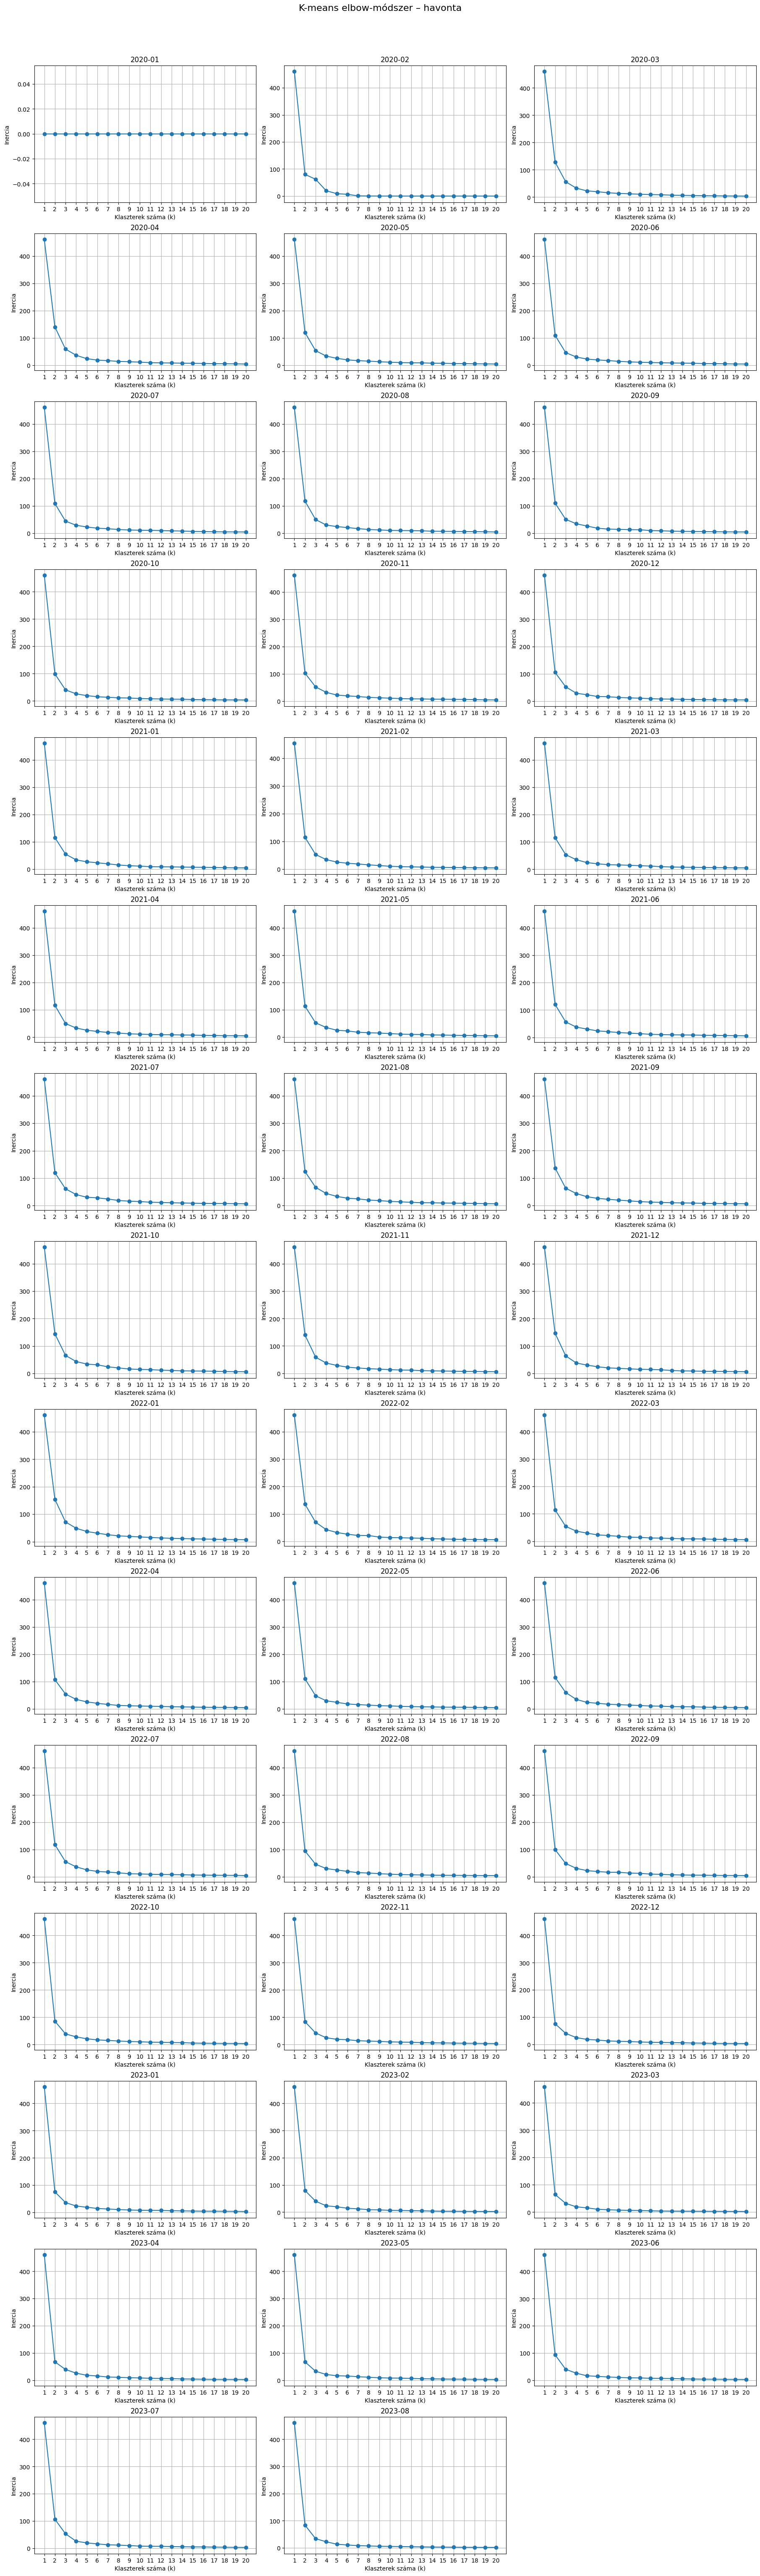

In [3]:
population = pd.read_csv("world-population.csv")
covid = pd.read_csv("covid-cases.csv")

population
covid

covid["Date_reported"] = pd.to_datetime(covid["Date_reported"])
month_end_df = covid[covid["Date_reported"].dt.is_month_end]
month_end_df

# Rendezés ország és dátum szerint
month_end_df = month_end_df.sort_values(by=["Country", "Date_reported"])

# Új oszlop létrehozása: havi új halálozás (különbség)
month_end_df["Monthly_deaths"] = month_end_df.groupby("Country")["Cumulative_deaths"].diff().fillna(0).astype(int)
month_end_df

import numpy as np

population_szurt = population[["CCA3", "Name", "2020", "2022", "Area (km²)",	"Density (per km²)",	"GrowthRate",	"World Population Percentage"]]

# 2021 népességének beállítjuk 2020 és 2022 átlagát
population_szurt["2021"] = population_szurt[["2020", "2022"]].mean(axis=1)

# 2023 népességére nincs adat, ezért 2022 népességét használjuk
population_szurt["2023"] = population_szurt["2022"]
population_szurt

# Év oszlop létrehozása
month_end_df['Year'] = month_end_df['Date_reported'].dt.year.astype(str)


# melt előtt szétválasztjuk a numerikus évek adatait
population_melted = population_szurt.melt(
    id_vars=['CCA3', 'Name', 'Area (km²)', 'Density (per km²)', 'GrowthRate', 'World Population Percentage'],
    value_vars=['2020', '2021', '2022', '2023'],
    var_name='Year',
    value_name='Population'
)

# Eredmény
print(population_melted.head())

# Ezután merge a month_end_df-vel
merged_df = pd.merge(
    month_end_df,
    population_melted,
    left_on=['Country_code', 'Year'],
    right_on=['CCA3', 'Year'],
    how='left',
    validate='m:1'  # many-to-one merge
)


# Eredmény: A merged_df DataFrame-ben már szerepel az adott évhez tartozó népességadat minden országhoz.

# Halálozási ráta kiszámítása 100.000 emberre
merged_df['Death_rate_per_100k'] = (merged_df['Monthly_deaths'] / merged_df['Population']) * 100000

merged_df.head()

# # Halálozási ráta kiszámítása 100.000 kilométerre
merged_df['Deaths_per_km2'] = merged_df['Monthly_deaths'] / merged_df['Area (km²)']*100000
merged_df.head()

# A merged_df sorrendbe rendezése hónapok, és azon belül országok szerint
merged_df = merged_df.sort_values(by=['Date_reported', 'Country'])

# A hónapok átalakítása Év-Hónap formátummá
merged_df['YearMonth'] = merged_df['Date_reported'].dt.to_period('M')

# Azon mezők leszűrése, amik fontosak lesznek nekünk a klaszterezésnél
merged_df = merged_df[["YearMonth", "Country", "Death_rate_per_100k", "Deaths_per_km2"]]
merged_df

# Korreláció vizsgálata a két halálozási ráta között
corr_matrix = merged_df[['Death_rate_per_100k', 'Deaths_per_km2']].corr()
print(corr_matrix)

# Mondhatjuk, hogy kb. gyenge a korreláció

# Két vizsgált oszlop
cols_to_check = ['Death_rate_per_100k', 'Deaths_per_km2']

# Ferdeség vizsgálata havonta
for month, group in merged_df.groupby('YearMonth'):
    skew_values = group[cols_to_check].skew().sort_values(ascending=False)
    high_skew = skew_values[skew_values > 0.75]
    
    if not high_skew.empty:
        print(f"\n{month}:")
        print(high_skew)

# Érdemes logaritmálni

# A két halálozási ráta logaritmálása
merged_df['Death_rate_per_100k'] = np.log1p(merged_df['Death_rate_per_100k'])
merged_df['Deaths_per_km2'] = np.log1p(merged_df['Deaths_per_km2'])

merged_df

from sklearn.preprocessing import StandardScaler

# Új DataFrame a skálázott eredményekhez
scaled_df = pd.DataFrame()

# Hónapra csoportosítás és skálázás
for month, group in merged_df.groupby('YearMonth'):
    scaler = StandardScaler()
    group_scaled = group.copy()
    group_scaled[cols_to_check] = scaler.fit_transform(group[cols_to_check])
    scaled_df = pd.concat([scaled_df, group_scaled], axis=0)

# Visszarendezés időrendbe
merged_df = scaled_df.sort_values(by=['YearMonth', 'Country']).reset_index(drop=True)

merged_df

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Csak azokat a sorokat nézzük, ahol a klaszterezési jellemzők elérhetőek
monthly_groups = merged_df.dropna(subset=cols_to_check).groupby('YearMonth')

# Maximum 12 subplot (1 évnyi)
n_months = len(monthly_groups)
n_cols = 3
n_rows = (n_months + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 4), constrained_layout=True)
axes = axes.flatten()

# Minden hónapra külön elbow ábra
for i, (month, group) in enumerate(monthly_groups):
    features = group[cols_to_check]
    inertia_values = []

    for k in range(1, 21):
        km = KMeans(n_clusters=k, random_state=42)
        km.fit(features)
        inertia_values.append(km.inertia_)

    ax = axes[i]
    ax.plot(range(1, 21), inertia_values, marker='o', linestyle='-')
    ax.set_title(f'{month}')
    ax.set_xlabel('Klaszterek száma (k)')
    ax.set_ylabel('Inercia')
    ax.grid(True)
    ax.set_xticks(range(1, 21))

# Ha marad üres subplot, töröljük
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# A diagramok ábrázolása
plt.suptitle('K-means elbow-módszer – havonta', fontsize=16, y=1.02)
plt.show()

# A megfelelő inertia: 5

In [4]:
# Modell készítése

from sklearn.cluster import KMeans

clustered_df = pd.DataFrame()
n_clusters = 5

for month, group in merged_df.groupby('YearMonth'):
    group = group.copy()
    
    # Csak azokat az országokat tartjuk meg, ahol mindkét érték ismert
    group = group.dropna(subset=['Death_rate_per_100k', 'Deaths_per_km2'])
    
    if len(group) >= n_clusters:
        features = group[['Death_rate_per_100k', 'Deaths_per_km2']]
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        group['Impact_cluster'] = kmeans.fit_predict(features)
        
        # Klaszterek sorrendbe állítása a halálozási ráta alapján
        cluster_order = (group.groupby('Impact_cluster')['Death_rate_per_100k']
                         .mean()
                         .sort_values()
                         .reset_index()
                         .reset_index()
                         .rename(columns={'index': 'Impact_score'}))
        
        # 0–4 -> 1–5
        group = group.merge(cluster_order, on='Impact_cluster')
        group['Impact_score'] += 1
        
        clustered_df = pd.concat([clustered_df, group], axis=0)

# Dátum és ország szerinti rendezés
clustered_df = clustered_df.sort_values(by=['YearMonth', 'Country']).reset_index(drop=True)

# 1: legalacsonyabb halálozás, 5: legmagasabb halálozás

# Országonként összegezve, hogy hány hónapban kaptak adott Impact_score-t
impact_summary = pd.crosstab(index=clustered_df['Country'], columns=clustered_df['Impact_score'])

# Oszlopok átnevezése (pl. Score_1, Score_2, stb.)
impact_summary.columns = [f'Score_{col}' for col in impact_summary.columns]

# Eredmény megtekintése
impact_summary.head()

# Top 10 ország, ahol legtöbbször szerepelt az 1-es score
top_10_score1 = impact_summary.sort_values(by='Score_1', ascending=False).head(10)

# Eredmény megjelenítése
print("Top 10 ország, akiknél a legtöbbször fordult elő az 1-es Impact_score:\n")
print(top_10_score1[['Score_1']])

total_months = clustered_df['YearMonth'].nunique()
print(f"Összesen {total_months} különböző hónap szerepel az adatokban.")



Top 10 ország, akiknél a legtöbbször fordult elő az 1-es Impact_score:

                                       Score_1
Country                                       
Holy See                                    44
Tokelau                                     44
Democratic People's Republic of Korea       44
Niue                                        44
Turkmenistan                                44
Falkland Islands (Malvinas)                 44
Tuvalu                                      43
Nauru                                       43
Marshall Islands                            43
Saint Pierre and Miquelon                   42
Összesen 44 különböző hónap szerepel az adatokban.


/opt/anaconda3/envs/exam_env/lib/python3.12/site-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


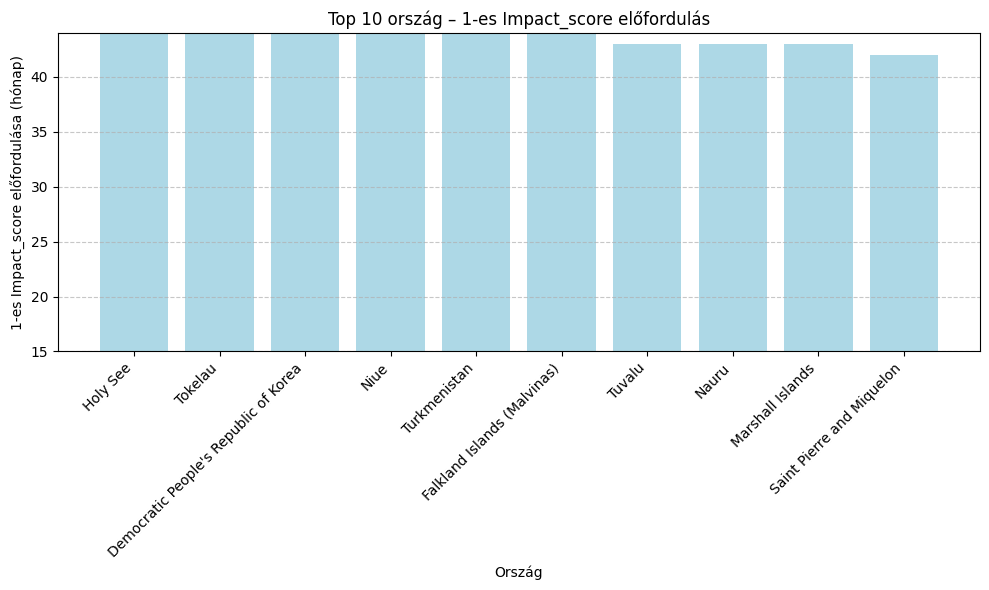

In [5]:
import matplotlib.pyplot as plt

# Diagram méretezés
plt.figure(figsize=(10, 6))

# Oszlopdiagram létrehozása
plt.bar(top_10_score1.index, top_10_score1['Score_1'], color='lightblue')

# Tengelyfeliratok és cím
plt.xlabel('Ország')
plt.ylabel('1-es Impact_score előfordulása (hónap)')
plt.title('Top 10 ország – 1-es Impact_score előfordulás')
plt.xticks(rotation=45, ha='right')  # Országnevek döntve, olvashatóbb
plt.ylim(15, 44)

# Rácsvonal
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Megjelenítés
plt.tight_layout()
plt.show()


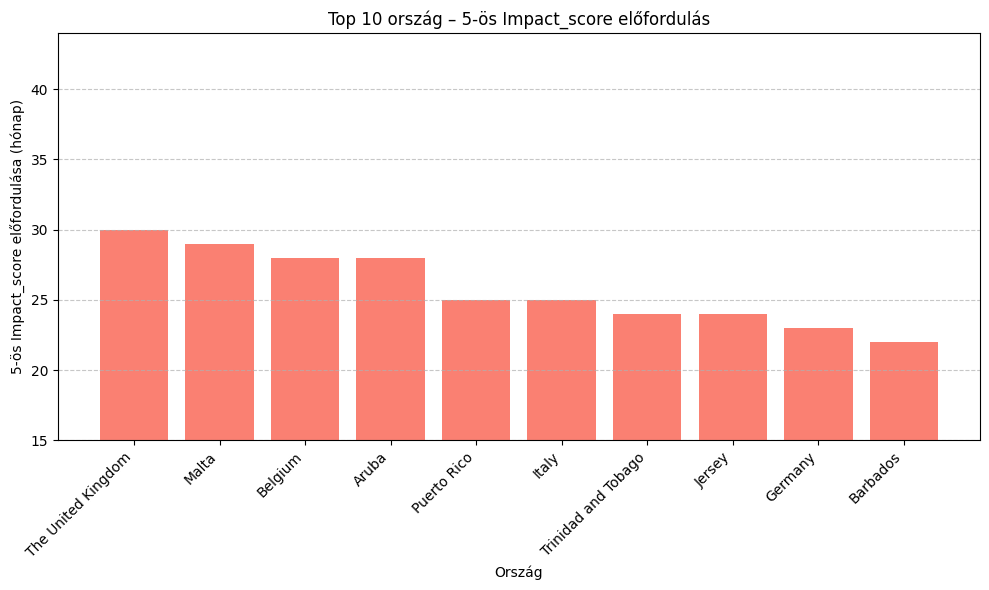

In [6]:
# Top 10 ország, ahol legtöbbször szerepelt az 5-ös score
top_10_score5 = impact_summary.sort_values(by='Score_5', ascending=False).head(10)

# Diagram méretezés
plt.figure(figsize=(10, 6))

# Oszlopdiagram létrehozása
plt.bar(top_10_score5.index, top_10_score5['Score_5'], color='salmon')

# Tengelyfeliratok és cím
plt.xlabel('Ország')
plt.ylabel('5-ös Impact_score előfordulása (hónap)')
plt.title('Top 10 ország – 5-ös Impact_score előfordulás')
plt.xticks(rotation=45, ha='right')

# Y-tengely tartomány beállítása
plt.ylim(15,44)

# Rácsvonal
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Megjelenítés
plt.tight_layout()
plt.show()

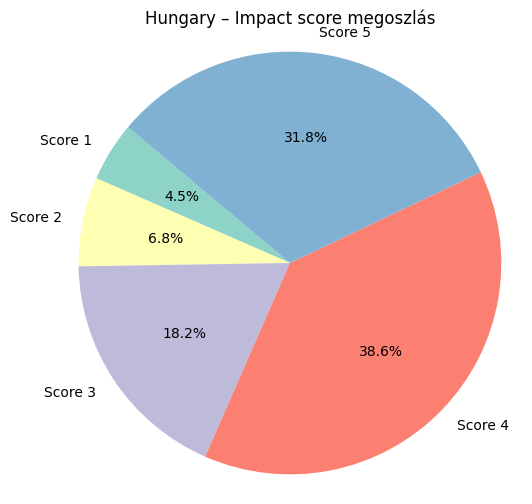

In [9]:
import tkinter as tk
from tkinter import simpledialog

# Tkinter input ablak létrehozása
root = tk.Tk()
root.withdraw()  # Elrejti a főablakot

# Ország bekérése popup ablakból
orszag = simpledialog.askstring(title="Ország beírása", prompt="Írj be egy országnevet (pl. Hungary):")

# Ellenőrzés, hogy nem üres-e a bevitel
if orszag is None or orszag.strip() == "":
    print("Nem adott meg országnevet.")
else:
    # Szűrés az adott országra
    orszag_data = clustered_df[clustered_df['Country'] == orszag]

    # Ellenőrzés, van-e adat
    if orszag_data.empty:
        print(f"Nincs adat az adott országra: {orszag}")
    else:
        # Előfordulások összesítése
        score_counts = orszag_data['Impact_score'].value_counts().sort_index()

        # Teljes lista biztosítása (1–5)
        for score in range(1, 6):
            if score not in score_counts:
                score_counts[score] = 0

        # Rendezés
        score_counts = score_counts.sort_index()

        # Kördiagram
        plt.figure(figsize=(6, 6))
        plt.pie(score_counts, labels=[f'Score {s}' for s in score_counts.index],
                autopct='%1.1f%%', startangle=140, colors=plt.cm.Set3.colors)

        plt.title(f'{orszag} – Impact score megoszlás')
        plt.axis('equal')  # Kör alak megtartása
        plt.show()


In [7]:
covid_waves = [
    ('1. hullám (2020 tavasz)', pd.Period('2020-01', freq='M'), pd.Period('2020-06', freq='M')),
    ('2. hullám (2020 ősz – 2021 tavasz)', pd.Period('2020-07', freq='M'), pd.Period('2021-03', freq='M')),
    ('3. hullám (2021 nyár – ősz)', pd.Period('2021-04', freq='M'), pd.Period('2021-11', freq='M')),
    ('4. hullám (2021 vége – 2022 tavasz)', pd.Period('2021-12', freq='M'), pd.Period('2022-05', freq='M')),
    ('5. hullám (2022 közép – vége)', pd.Period('2022-06', freq='M'), pd.Period('2023-12', freq='M')),
]

# Adott hónaphoz Covid hullámot rendelünk
def assign_covid_wave(row):
    ym = row['YearMonth']
    if not isinstance(ym, pd.Period):
        ym = pd.Period(str(ym), freq='M')
    for wave_name, start, end in covid_waves:
        if start <= ym <= end:
            return wave_name
    # Ha valamiért nem esik egyik hullámba sem, akkor egy alapértelmezett érték
    return 'Ismeretlen időszak'

clustered_df['Covid_wave'] = clustered_df.apply(assign_covid_wave, axis=1)
clustered_df

,YearMonth,Country,Death_rate_per_100k_x,Deaths_per_km2,Impact_cluster,Impact_score,Death_rate_per_100k_y,Covid_wave
0,2020-01,Afghanistan,0.000000,0.000000,0,1,0.000000,1. hullám (2020 tavasz)
1,2020-01,Albania,0.000000,0.000000,0,1,0.000000,1. hullám (2020 tavasz)
2,2020-01,Algeria,0.000000,0.000000,0,1,0.000000,1. hullám (2020 tavasz)
3,2020-01,American Samoa,0.000000,0.000000,0,1,0.000000,1. hullám (2020 tavasz)
4,2020-01,Andorra,0.000000,0.000000,0,1,0.000000,1. hullám (2020 tavasz)
...,...,...,...,...,...,...,...,...
10111,2023-08,Wallis and Futuna,-0.469592,-0.402939,0,1,-0.465646,5. hullám (2022 közép – vége)
10112,2023-08,Yemen,-0.469592,-0.402939,0,1,-0.465646,5. hullám (2022 közép – vége)
10113,2023-08,Zambia,-0.469592,-0.402939,0,1,-0.465646,5. hullám (2022 közép – vége)
10114,2023-08,Zimbabwe,1.159380,0.189698,2,2,1.044865,5. hullám (2022 közép – vége)


In [9]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "browser"

# Lista az egyedi hullámnevekről, sorrendben
waves = clustered_df['Covid_wave'].unique()

# Hullámonként térképdiagram készítése
for wave in waves:
    # Szűrés adott hullámra
    wave_data = clustered_df[clustered_df['Covid_wave'] == wave]
    
    # Országonként az átlagos Impact_score számítása az adott hullámban
    avg_scores = wave_data.groupby('Country')['Impact_score'].mean().reset_index()
    
    # Térképes megjelenítés
    fig = px.choropleth(
        avg_scores,
        locations="Country",
        locationmode="country names",
        color="Impact_score",
        color_continuous_scale="Reds",
        title=f"Országonkénti átlagos Impact_score - {wave}"
    )
    
    fig.show()

## 4. Feladat

### Panel OLS modellt építettünk végül, ahol kettős indexelést használtunk (ország és időpont), magyarázóváltozó pedig az új fertőzött volt. A modellből tudtunk paramétereket becsülni, aminek segítségével általános egyenletet fel lehet írni bármely ország halotti számának becslésére adott időpontban adott új fertőzött mellett

In [10]:
import numpy as np
covid = pd.read_csv("covid-cases.csv")
covid.head(15)
#adatok regresszióra való betöltése
covid['Date_reported'] = pd.to_datetime(covid['Date_reported'])
covid = covid.sort_values(['Country', 'Date_reported'])
covid = covid.set_index(['Country', 'Date_reported'])
print(covid.index.names)

from linearmodels.panel import PanelOLS
import statsmodels.api as sm

covid['const'] = 1
vars = ['const', 'New_cases']
model = PanelOLS(covid['New_deaths'], covid[vars], entity_effects=True)

result = model.fit()

print(result.summary)

['Country', 'Date_reported']
                          PanelOLS Estimation Summary                           
Dep. Variable:             New_deaths   R-squared:                        0.0786
Estimator:                   PanelOLS   R-squared (Between):              0.1463
No. Observations:              323268   R-squared (Within):               0.0786
Date:                Sun, May 18 2025   R-squared (Overall):              0.0961
Time:                        19:05:41   Log-likelihood                -2.015e+06
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                   2.755e+04
Entities:                         237   P-value                           0.0000
Avg Obs:                       1364.0   Distribution:                F(1,323030)
Min Obs:                       1364.0                                           
Max Obs:                       1364.0   F-statistic (robust):          2.755e+04

In [ ]:
#lakosságszám figyelembe vétele
pop = pd.read_csv("world-population.csv")
pop.head(10)
pop = pop.rename(columns={"Name":"Country"})
print(covid.columns)
merged = covid.merge(pop[["Country", "2022", "2015", "2010", "2000", "1990", "1980", "1970"]], on="Country", how="left")
merged["Date"] = covid.reset_index()["Date_reported"]

merged['const'] = 1
merged = merged.set_index(["Country", "Date"])

vars = ["New_cases"]
regression_data = merged[vars + ['New_deaths']].replace([np.inf, -np.inf], np.nan).dropna()
model2 = PanelOLS(regression_data['New_deaths'], regression_data[vars], entity_effects=True, drop_absorbed=True)
result2 = model2.fit()

print(result2.summary)

Index(['Country_code', 'WHO_region', 'New_cases', 'Cumulative_cases',
       'New_deaths', 'Cumulative_deaths', 'const'],
      dtype='object')
                          PanelOLS Estimation Summary                           
Dep. Variable:             New_deaths   R-squared:                        0.0786
Estimator:                   PanelOLS   R-squared (Between):              0.1501
No. Observations:              323268   R-squared (Within):               0.0786
Date:                Sun, May 18 2025   R-squared (Overall):              0.0981
Time:                        19:05:44   Log-likelihood                -2.015e+06
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                   2.755e+04
Entities:                         237   P-value                           0.0000
Avg Obs:                       1364.0   Distribution:                F(1,323030)
Min Obs:                       1364.0         

In [ ]:
#modellek értelmezése
print(result2.params)
print(result2.estimated_effects.loc['Hungary'])

## Panel OLS regressziós egyenlet Magyarországra
New Deaths (Hungary, 2023-09-27) = alpha(Hungary) + beta * new_cases(Hungary, 2023-09-27) + e
alpha(Hungary) = 34.26
beta = 0.00094

### Példa: 
2023-09-28-án 3000 új eset jelenik meg
New Deaths = 34.26 + 0.00094 * 3000
--> 38 új halálesetet jelent



34.26 + 0.00094 * 3000

### Megj: viszont mivel a panel OLS modellben megfigyelésen alapuló előrejelzést lehet készíteni az együtthatók segítéségével (fixed effects panel), ezért nem tudunk hosszú időtávra előrejelezni, mert ahhoz más, idősor alapú elemzéssel trendet kellett volna becsülni, amit nem tudunk regresszióval megtenni